In [1]:
#!pip install pandas
import pandas as pd

In [2]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
spark = SparkSession.builder.getOrCreate()

In [3]:
# reading a CSV file into a Spark DataFrame
df = spark.read.csv("nuclear_plants_small_dataset.csv",header=True,inferSchema=True)
df.printSchema() # prints the schema of the DataFrame on the console/log
df.show() # displays the contents of the DataFrame in a row and column table format

root
 |-- Status: string (nullable = true)
 |-- Power_range_sensor_1: double (nullable = true)
 |-- Power_range_sensor_2: double (nullable = true)
 |-- Power_range_sensor_3 : double (nullable = true)
 |-- Power_range_sensor_4: double (nullable = true)
 |-- Pressure _sensor_1: double (nullable = true)
 |-- Pressure _sensor_2: double (nullable = true)
 |-- Pressure _sensor_3: double (nullable = true)
 |-- Pressure _sensor_4: double (nullable = true)
 |-- Vibration_sensor_1: double (nullable = true)
 |-- Vibration_sensor_2: double (nullable = true)
 |-- Vibration_sensor_3: double (nullable = true)
 |-- Vibration_sensor_4: double (nullable = true)

+------+--------------------+--------------------+---------------------+--------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|Status|Power_range_sensor_1|Power_range_sensor_2|Power_range_sensor_3 |Power_range_sensor_4|Pressure

In [4]:
#Task 1

df2 = df.groupBy("Status").count() # counts the number of rows, grouping the same "Status"'s together'
df2.show()
df3 = df.dropna(how = "any") # removes rows containing any empty cells/nulls
df4 = df3.groupBy("Status").count()
df4.show()

+--------+-----+
|  Status|count|
+--------+-----+
|Abnormal|  498|
|  Normal|  498|
+--------+-----+

+--------+-----+
|  Status|count|
+--------+-----+
|Abnormal|  498|
|  Normal|  498|
+--------+-----+



In [5]:
# Task 2

import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql.functions import percentile_approx

dfNormalStatus = df.where(df.Status == "Normal") # creates a subDataFrame of only rows where "Status" == "Normal"
dfAbnormalStatus = df.where(df.Status == "Abnormal") # creates a subDataFrame of only rows where "Status" == "Abnormal"
pdNormalStatus = dfNormalStatus.toPandas() # creates a panda DataFrame
pdAbnormalStatus = dfAbnormalStatus.toPandas() # creates a panda DataFrame

pdNormalStatus.describe().loc[['min','max','mean','50%']] 
# generates descriptive summary statistics descibing the dataset's distribution
# parameters given under ".loc" specificy which statistics to calculate and return

,Power_range_sensor_1,Power_range_sensor_2,Power_range_sensor_3,Power_range_sensor_4,Pressure _sensor_1,Pressure _sensor_2,Pressure _sensor_3,Pressure _sensor_4,Vibration_sensor_1,Vibration_sensor_2,Vibration_sensor_3,Vibration_sensor_4
min,0.085100,0.040300,4.382600,0.154700,0.024800,0.010400,0.077400,0.00580,0.009200,0.027700,0.064600,0.083100
max,12.129800,11.928400,14.098200,16.356800,56.856200,9.221200,12.647500,15.10850,31.498100,34.867600,53.238400,43.231400
mean,5.602453,6.844503,9.292054,8.701398,13.797526,3.415646,5.923353,5.58618,8.441437,9.699616,19.437804,10.925098
50%,5.178650,6.717650,9.262850,9.240850,10.634800,3.113000,5.739400,4.25915,7.449900,8.700750,16.464500,9.485450


In [6]:
pdAbnormalStatus.describe().loc[['min','max','mean','50%']]

,Power_range_sensor_1,Power_range_sensor_2,Power_range_sensor_3,Power_range_sensor_4,Pressure _sensor_1,Pressure _sensor_2,Pressure _sensor_3,Pressure _sensor_4,Vibration_sensor_1,Vibration_sensor_2,Vibration_sensor_3,Vibration_sensor_4
min,0.008200,0.389100,2.583966,0.062300,0.131478,0.008262,0.001224,0.029478,0.000000,0.018500,0.131784,0.009200
max,10.923078,10.154100,15.759900,17.235858,67.979400,10.242738,11.772400,16.555620,36.186438,34.331466,36.911454,26.466900
mean,4.396695,5.914043,9.164170,6.009146,14.600728,2.740270,5.575115,4.407824,7.887689,10.303570,10.938159,8.942085
50%,4.513550,5.932218,9.472050,5.399300,12.596150,2.382689,5.744257,3.322575,6.535950,8.973100,8.987269,8.137600


Text(0.5, 1.0, 'Status - Normal')

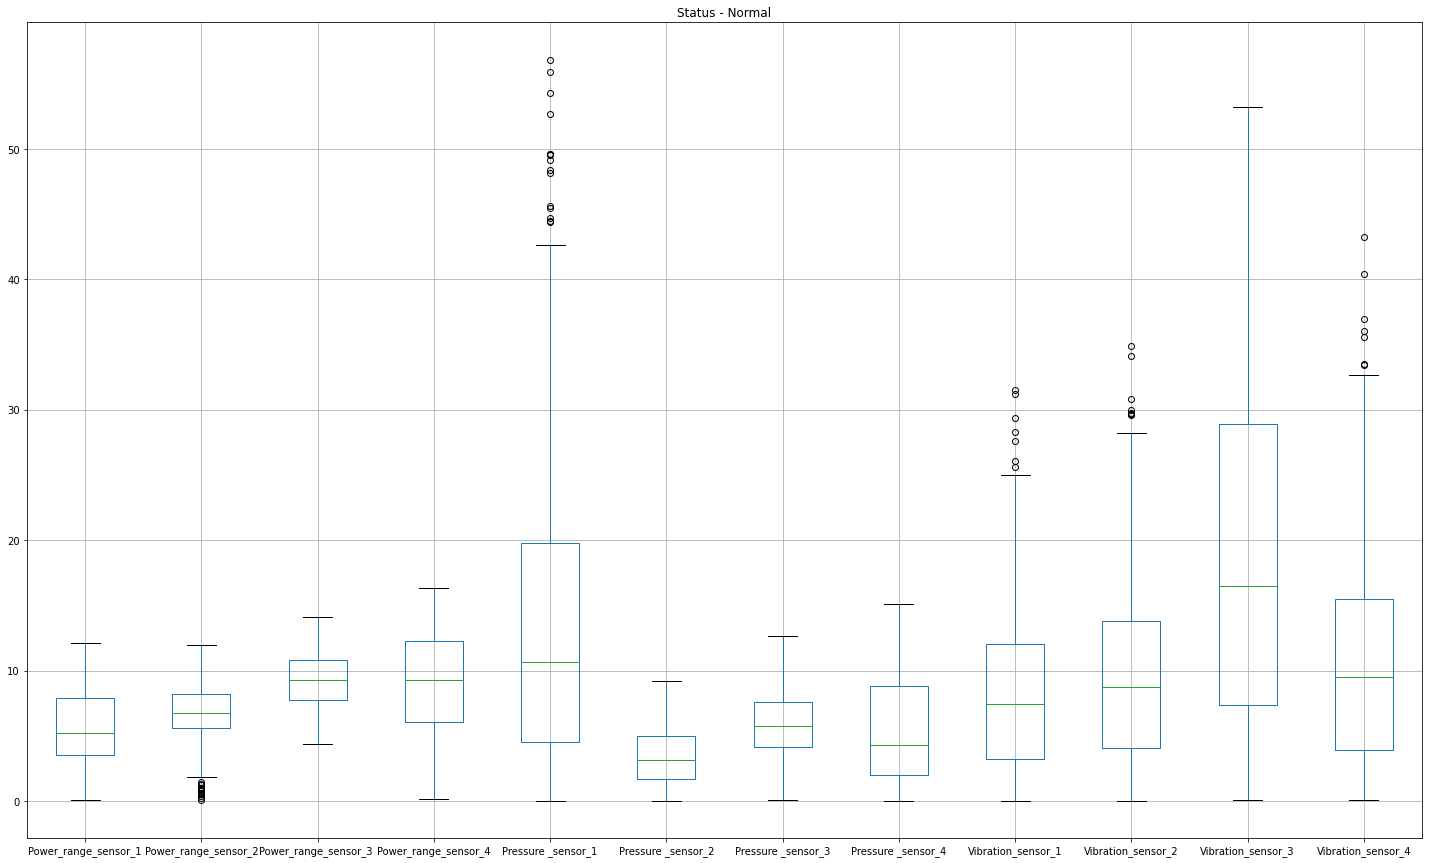

In [7]:
boxplot = pdNormalStatus.boxplot(figsize = (25,15), showfliers = True)
boxplot.set_title("Status - Normal")
# generating a pandas boxplot, including to show any outliers

Text(0.5, 1.0, 'Status - Abnormal')

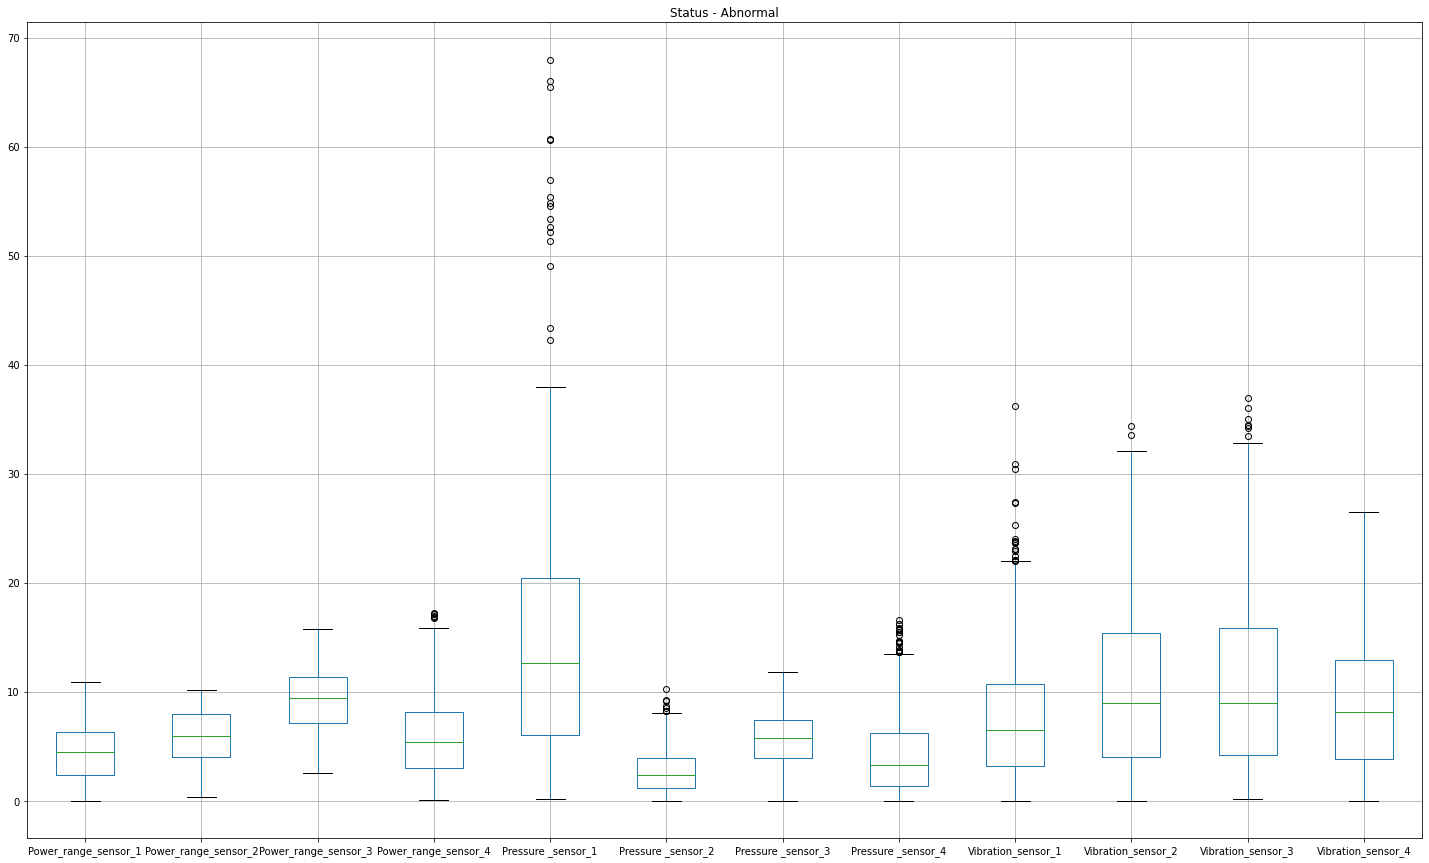

In [8]:
boxplot = pdAbnormalStatus.boxplot(figsize = (25,15), showfliers = True)
boxplot.set_title("Status - Abnormal")

In [9]:
# Task 3

dataPanda = pd.read_csv("nuclear_plants_small_dataset.csv")
corr = dataPanda.corr(method='pearson')
# calculates a pairwise correlation of columns in the dataset, "pearson" being the standard correlation coefficient, unless specified to "spearman"
corr.style.background_gradient(cmap = 'coolwarm')
# setting the style of the correlation matrix to be displayed as a heatmap to visualise the correlations on a colour scale

,Power_range_sensor_1,Power_range_sensor_2,Power_range_sensor_3,Power_range_sensor_4,Pressure _sensor_1,Pressure _sensor_2,Pressure _sensor_3,Pressure _sensor_4,Vibration_sensor_1,Vibration_sensor_2,Vibration_sensor_3,Vibration_sensor_4
Power_range_sensor_1,1.000000,0.095235,0.229943,0.499795,0.047805,0.652081,0.199811,0.406382,-0.152247,-0.003684,0.106583,0.014177
Power_range_sensor_2,0.095235,1.000000,0.693818,0.228438,-0.222160,0.112438,0.583086,0.136380,-0.119142,0.011013,0.243242,0.058244
Power_range_sensor_3,0.229943,0.693818,1.000000,0.083362,-0.255865,0.166549,0.362688,0.062479,-0.249057,-0.038320,0.215811,-0.023962
Power_range_sensor_4,0.499795,0.228438,0.083362,1.000000,0.150635,0.567705,-0.070547,0.823637,-0.114117,0.043383,0.330499,-0.018193
Pressure _sensor_1,0.047805,-0.222160,-0.255865,0.150635,1.000000,0.116859,-0.118713,0.131136,0.101438,-0.035196,-0.084575,-0.125128
Pressure _sensor_2,0.652081,0.112438,0.166549,0.567705,0.116859,1.000000,0.091341,0.571403,-0.099950,-0.027698,0.011015,0.001189
Pressure _sensor_3,0.199811,0.583086,0.362688,-0.070547,-0.118713,0.091341,1.000000,0.001591,0.016497,0.029766,0.019993,0.105642
Pressure _sensor_4,0.406382,0.136380,0.062479,0.823637,0.131136,0.571403,0.001591,1.000000,-0.112696,0.010560,0.191842,0.047000
Vibration_sensor_1,-0.152247,-0.119142,-0.249057,-0.114117,0.101438,-0.099950,0.016497,-0.112696,1.000000,-0.045857,-0.076277,0.026480
Vibration_sensor_2,-0.003684,0.011013,-0.038320,0.043383,-0.035196,-0.027698,0.029766,0.010560,-0.045857,1.000000,0.103704,-0.023290


In [10]:
# Task 4

from pyspark.ml.feature import VectorAssembler, StringIndexer
assem = VectorAssembler(inputCols = df.columns[1:], outputCol = 'vec_col')
# VectorAssembler is a transformer that merges multiple columns into a vector column
#       in this case, "df.columns[1:]" are all of the columns in the CSV file except the first column "Status"
df2_Vec = assem.transform(df)
# transforms the input into a transformed dataset DataFrame
indexer = StringIndexer(inputCol="Status", outputCol="statusIndex")
# an indexer that maps a string column of labels to a column of label indices
df_ml = indexer.fit(df2_Vec).transform(df2_Vec)
# ".fit" fits a model to the input dataset, in this case - df2_Vec, into a dataFrame

trainingData, testData = df_ml.randomSplit([0.7,0.3], seed = 34) # Splits data,
#     setting a seed means the results are replicated with every run, otherwise different results from the random 
#     split occur each time
print("Training Data: ", trainingData.count())
trainingData.groupBy('Status').count().show()
print("Testing Data: ", testData.count())
testData.groupBy('Status').count().show()
# printing the number of rows containing in each dataset from the split - training/testing data

Training Data:  697
+--------+-----+
|  Status|count|
+--------+-----+
|Abnormal|  346|
|  Normal|  351|
+--------+-----+

Testing Data:  299
+--------+-----+
|  Status|count|
+--------+-----+
|Abnormal|  152|
|  Normal|  147|
+--------+-----+



In [12]:
# Task 5

from pyspark.ml.classification import DecisionTreeClassifier, LinearSVC, MultilayerPerceptronClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Decision Tree

decision_Tree = DecisionTreeClassifier(labelCol="statusIndex", featuresCol="vec_col")
model = decision_Tree.fit(trainingData) # trains the decision tree classifier to the training dataset
x = model.transform(testData) # applies the trained decision tree classifier to the testing dataset/DataFrame

evaluation = MulticlassClassificationEvaluator(labelCol="statusIndex", predictionCol="prediction", metricName="accuracy")
# ^ MulticlassClassificationEvaluator is a pyspark evaluator for multiclass classification
# calculates the result of the given parameter evaluation type - e.g. metricName = "accuracy"
tree_Accuracy = evaluation.evaluate(x.select("statusIndex", "prediction"))
print("Decision Tree:::\nAccuracy: ", tree_Accuracy)
evaluation = MulticlassClassificationEvaluator(labelCol="statusIndex", predictionCol="prediction", metricName="precisionByLabel")
#      same MulticlassClassificationEvalutor as above, 
#      but with specifying "precisionByLabel" as it's metricName to calculate
#      the classifier's sensitivity, which is evaluating a model's ability 
#      to predict the true positives of each category 
tree_Sensitivity = evaluation.evaluate(x.select("statusIndex", "prediction"))
print("Sensitivity: ", tree_Sensitivity)
evaluation = MulticlassClassificationEvaluator(labelCol="statusIndex", predictionCol="prediction", metricName="recallByLabel")
#      same MulticlassClassificationEvalutor as above, 
#      but with specifying "recallByLabel" as it's metricName to calculate
#      the classifier's specificity, which is evaluating a model's ability 
#      to predict a true negative of each category 
tree_Specificity = evaluation.evaluate(x.select("statusIndex", "prediction"))
print("Specificity: ", tree_Specificity)
print("Error Rate: ", 1 - tree_Accuracy)

# Support Vector Machine

support_Vector_Machine = LinearSVC(maxIter=10, regParam=0.1, labelCol="statusIndex", featuresCol="vec_col")
vm_Model = support_Vector_Machine.fit(trainingData) # trains the support vector machine model classifier to the training dataset
y = vm_Model.transform(testData) # applies the trained support vector machine model classifier to the testing dataset/DataFrame

evaluation = MulticlassClassificationEvaluator(labelCol="statusIndex", predictionCol="prediction", metricName="accuracy")
VM_accuracy = evaluation.evaluate(y.select("statusIndex", "prediction"))
print("\nSupport Vector Machine:::\nAccuracy: ", VM_accuracy)
evaluation = MulticlassClassificationEvaluator(labelCol="statusIndex", predictionCol="prediction", metricName="precisionByLabel")
VM_Sensitivity = evaluation.evaluate(y.select("statusIndex", "prediction"))
print("Sensitivity: ", VM_Sensitivity)
evaluation = MulticlassClassificationEvaluator(labelCol="statusIndex", predictionCol="prediction", metricName="recallByLabel")
VM_Specificity = evaluation.evaluate(y.select("statusIndex", "prediction"))
print("Specificity: ", VM_Specificity)
print("Error Rate: ", 1 - VM_accuracy)

# Artificial Neural Network

ANN = MultilayerPerceptronClassifier(maxIter=100, layers=[12,5,4,2], blockSize=128, seed=1, labelCol="statusIndex", featuresCol="vec_col")
ANN_Model = ANN.fit(trainingData) # trains the artificial neural network classifier to the training dataset
z = ANN_Model.transform(testData) # applies the trained artificial neural network classifier to the testing dataset/DataFrame

evaluation = MulticlassClassificationEvaluator(labelCol="statusIndex", predictionCol="prediction", metricName="accuracy")
ANN_accuracy = evaluation.evaluate(z.select("statusIndex", "prediction"))
print("\nArtificial Neural Network:::\nAccuracy: ", ANN_accuracy)
evaluation = MulticlassClassificationEvaluator(labelCol="statusIndex", predictionCol="prediction", metricName="precisionByLabel")
ANN_Sensitivity = evaluation.evaluate(z.select("statusIndex", "prediction"))
print("Sensitivity: ", ANN_Sensitivity)
evaluation = MulticlassClassificationEvaluator(labelCol="statusIndex", predictionCol="prediction", metricName="recallByLabel")
ANN_Specificity = evaluation.evaluate(z.select("statusIndex", "prediction"))
print("Specificity: ", ANN_Specificity)
print("Error Rate: ", 1 - ANN_accuracy)



Decision Tree:::
Accuracy:  0.822742474916388
Sensitivity:  0.8113207547169812
Specificity:  0.8486842105263158
Error Rate:  0.17725752508361203

Support Vector Machine:::
Accuracy:  0.7525083612040134
Sensitivity:  0.7349397590361446
Specificity:  0.8026315789473685
Error Rate:  0.24749163879598657

Artificial Neural Network:::
Accuracy:  0.7424749163879598
Sensitivity:  0.7027027027027027
Specificity:  0.8552631578947368
Error Rate:  0.2575250836120402
